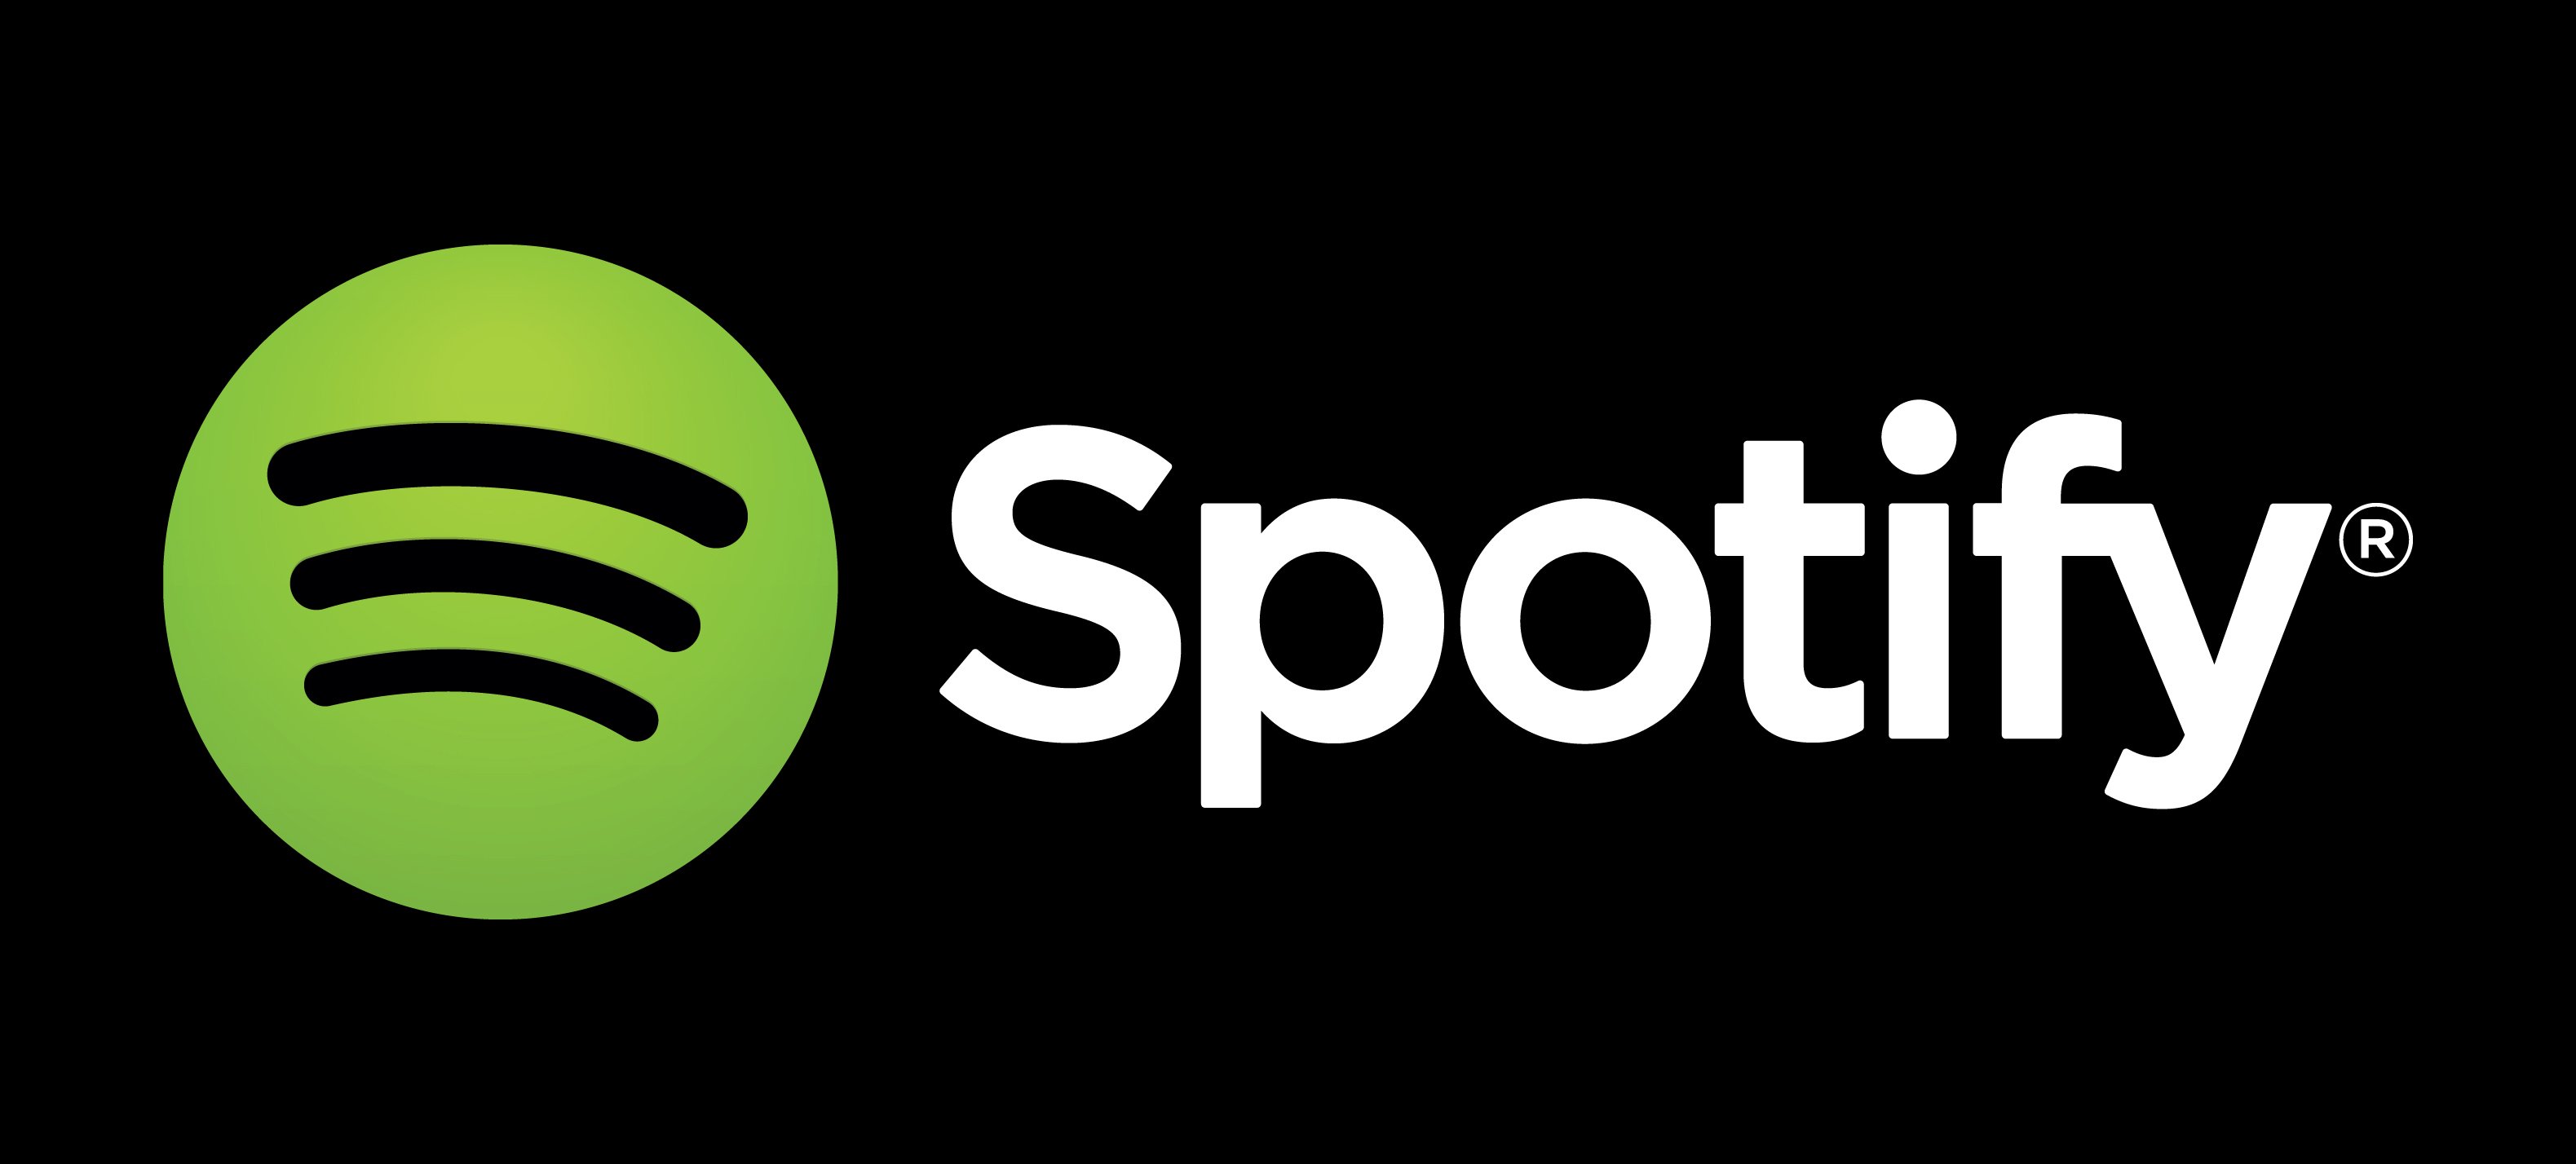

Spotify Music Genre Classificaton 🎧

In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

Loading the Dataset ⏳

In [224]:
music_dataset = pd.read_csv('Spotify Dataset.csv')
music_dataset

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [225]:
music_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [226]:
music_dataset.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Preprocessing the Data 🛠️

In [227]:
print(music_dataset.isnull().sum())
print('\nthe number of null values is: ', music_dataset.isnull().sum().sum())

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

the number of null values is:  3


In [228]:
print(music_dataset.nunique())
print('\nthe number of unique values is: ', music_dataset.nunique().sum())


Unnamed: 0          114000
track_id             89741
artists              31437
album_name           46579
track_name           73601
popularity             101
duration_ms          50697
explicit                 2
danceability          1174
energy                2083
key                     12
loudness             19480
mode                     2
speechiness           1489
acousticness          5061
instrumentalness      5346
liveness              1722
valence               1790
tempo                45653
time_signature           5
track_genre            114
dtype: int64

the number of unique values is:  490089


In [229]:
print(music_dataset.duplicated())
print('\nthe number of duplicated values is: ', music_dataset.duplicated().sum())

0         False
1         False
2         False
3         False
4         False
          ...  
113995    False
113996    False
113997    False
113998    False
113999    False
Length: 114000, dtype: bool

the number of duplicated values is:  0


In [230]:
#now removing the useless features in the dataset
music_dataset.drop(['track_id', 'artists', 'album_name', 'track_name'], axis = 1, inplace = True)

In [231]:
music_dataset

,Unnamed: 0,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [232]:
music_dataset.drop(['Unnamed: 0'], axis = 1, inplace = True)

In [233]:
music_dataset

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [234]:
original_column_names = music_dataset['track_genre']
original_column_names

0            acoustic
1            acoustic
2            acoustic
3            acoustic
4            acoustic
             ...     
113995    world-music
113996    world-music
113997    world-music
113998    world-music
113999    world-music
Name: track_genre, Length: 114000, dtype: object

In [235]:
#now label encoding
le = LabelEncoder()
music_dataset['explicit'] = le.fit_transform(music_dataset['explicit'])
music_dataset['track_genre'] = le.fit_transform(music_dataset['track_genre'])
music_dataset

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,0
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,0
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,0
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,0
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,0,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,113
113996,22,385000,0,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,113
113997,22,271466,0,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,113
113998,41,283893,0,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,113


In [236]:
#now scaling the dataset
column_names = music_dataset.columns
mnmx = MinMaxScaler()
music_dataset = mnmx.fit_transform(music_dataset)
music_dataset = pd.DataFrame(music_dataset, columns = column_names)
music_dataset

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0.73,0.044043,0.0,0.686294,0.4610,0.090909,0.791392,0.0,0.148187,0.032329,0.000001,0.3580,0.718593,0.361245,0.8,0.0
1,0.55,0.028566,0.0,0.426396,0.1660,0.090909,0.597377,1.0,0.079067,0.927711,0.000006,0.1010,0.268342,0.318397,0.8,0.0
2,0.57,0.040255,0.0,0.444670,0.3590,0.000000,0.736123,1.0,0.057720,0.210843,0.000000,0.1170,0.120603,0.313643,0.8,0.0
3,0.71,0.038557,0.0,0.270051,0.0596,0.000000,0.573701,1.0,0.037617,0.908635,0.000071,0.1320,0.143719,0.746758,0.6,0.0
4,0.82,0.037969,0.0,0.627411,0.4430,0.181818,0.737103,1.0,0.054508,0.470884,0.000000,0.0829,0.167839,0.492863,0.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,0.21,0.073511,0.0,0.174619,0.2350,0.454545,0.612952,1.0,0.043731,0.642570,0.928000,0.0863,0.034070,0.517705,1.0,1.0
113996,0.22,0.073511,0.0,0.176650,0.1170,0.000000,0.577345,0.0,0.041554,0.997992,0.976000,0.1050,0.035176,0.350242,0.8,1.0
113997,0.22,0.051833,0.0,0.638579,0.3290,0.000000,0.714648,0.0,0.043523,0.870482,0.000000,0.0839,0.746734,0.543933,0.8,1.0
113998,0.41,0.054206,0.0,0.595939,0.5060,0.636364,0.714759,1.0,0.030777,0.382530,0.000000,0.2700,0.415075,0.558651,0.8,1.0


Exploratory Data Analysis 🧐📊

<Figure size 1000x500 with 0 Axes>

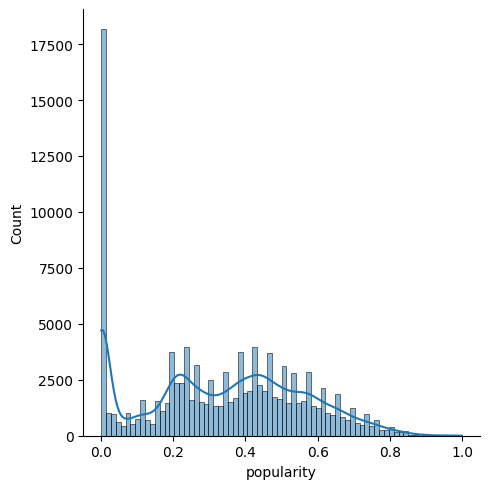

<Figure size 1000x500 with 0 Axes>

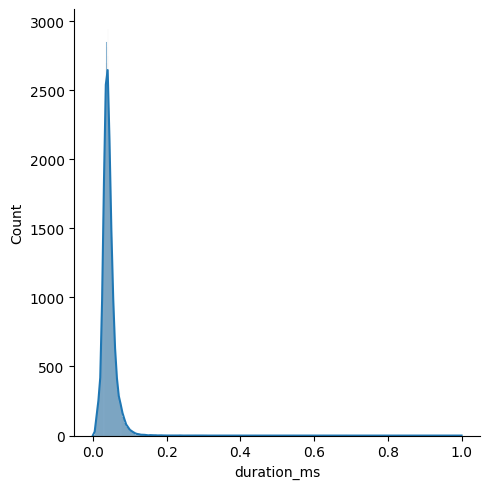

<Figure size 1000x500 with 0 Axes>

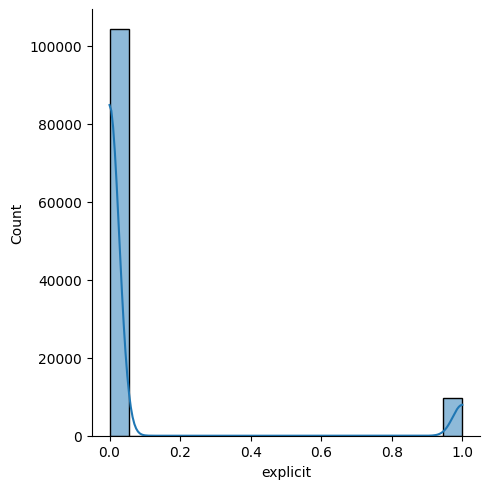

<Figure size 1000x500 with 0 Axes>

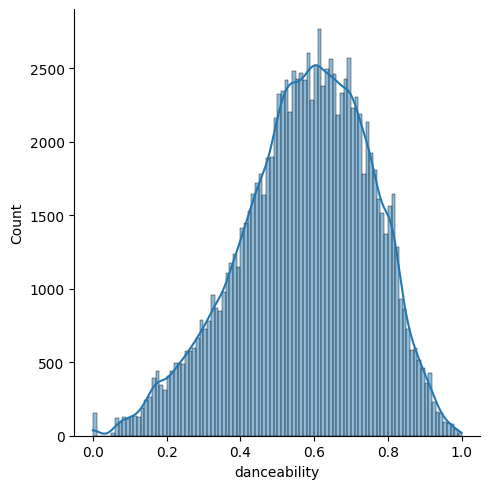

<Figure size 1000x500 with 0 Axes>

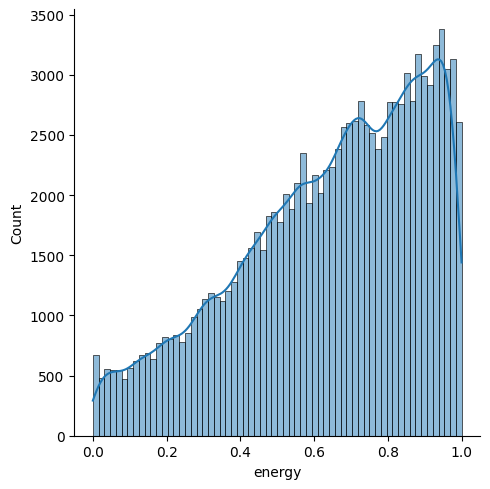

<Figure size 1000x500 with 0 Axes>

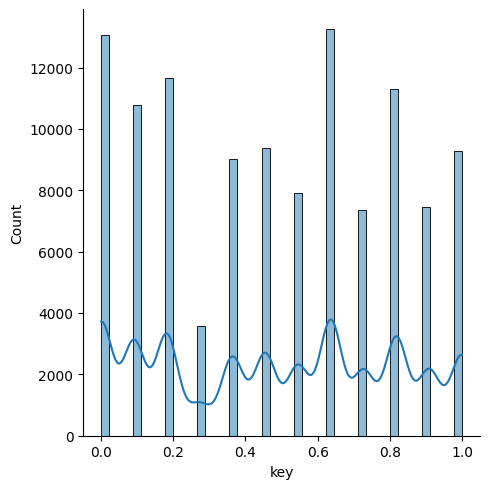

<Figure size 1000x500 with 0 Axes>

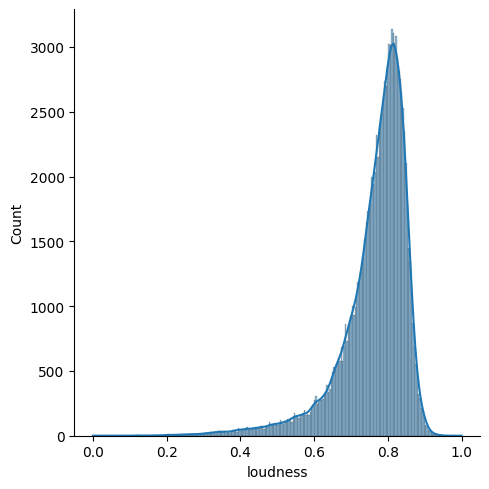

<Figure size 1000x500 with 0 Axes>

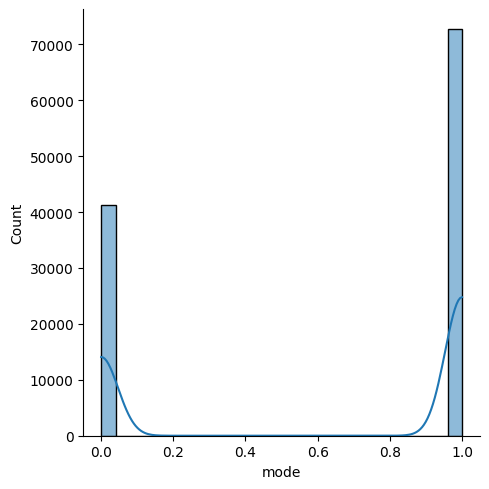

<Figure size 1000x500 with 0 Axes>

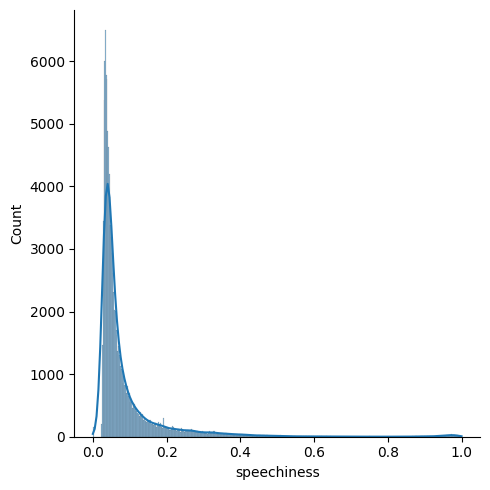

<Figure size 1000x500 with 0 Axes>

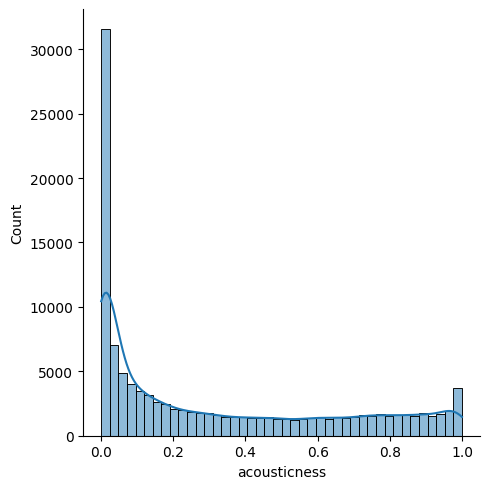

<Figure size 1000x500 with 0 Axes>

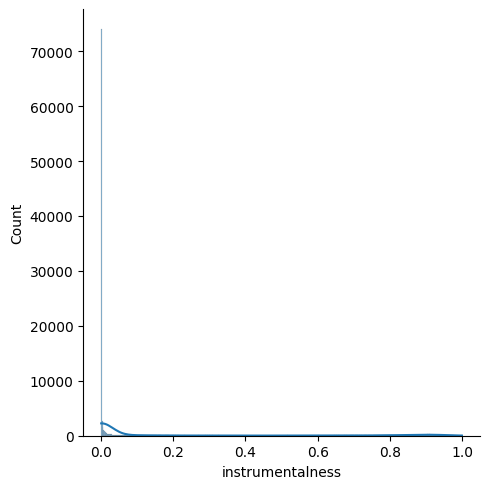

<Figure size 1000x500 with 0 Axes>

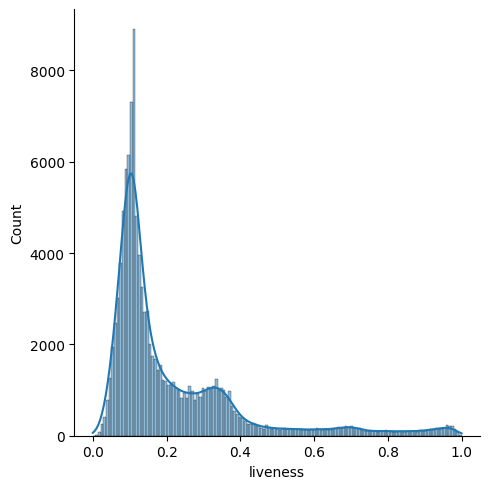

<Figure size 1000x500 with 0 Axes>

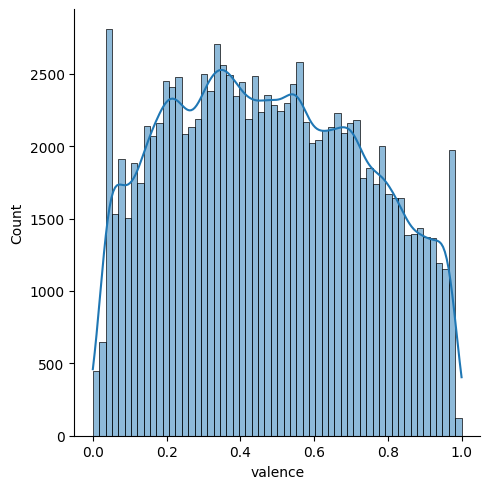

<Figure size 1000x500 with 0 Axes>

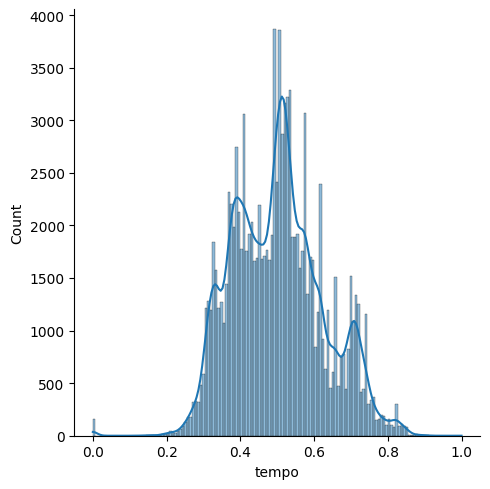

<Figure size 1000x500 with 0 Axes>

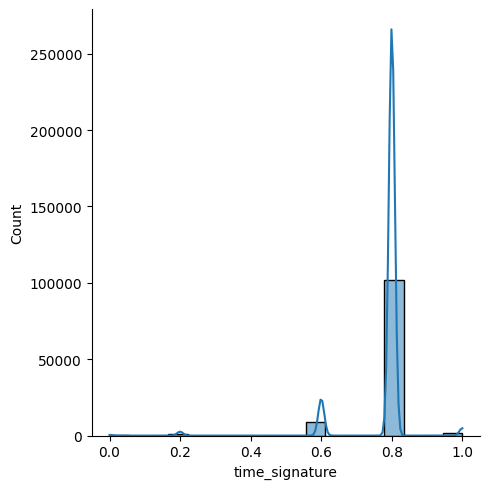

<Figure size 1000x500 with 0 Axes>

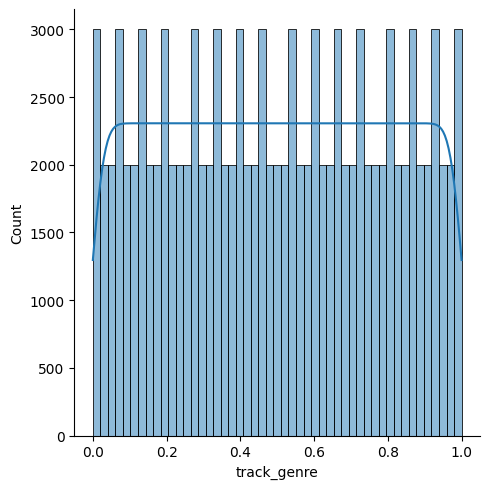

In [237]:
#histogram of dataset one by one
features = music_dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.displot(music_dataset[feature], kde = True)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

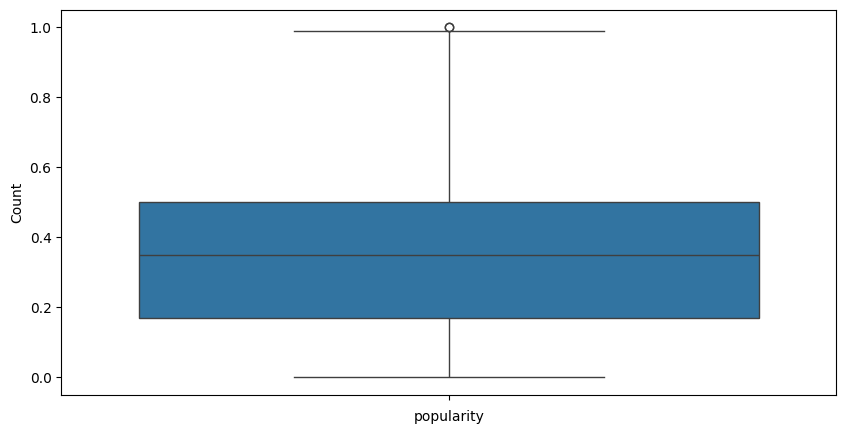

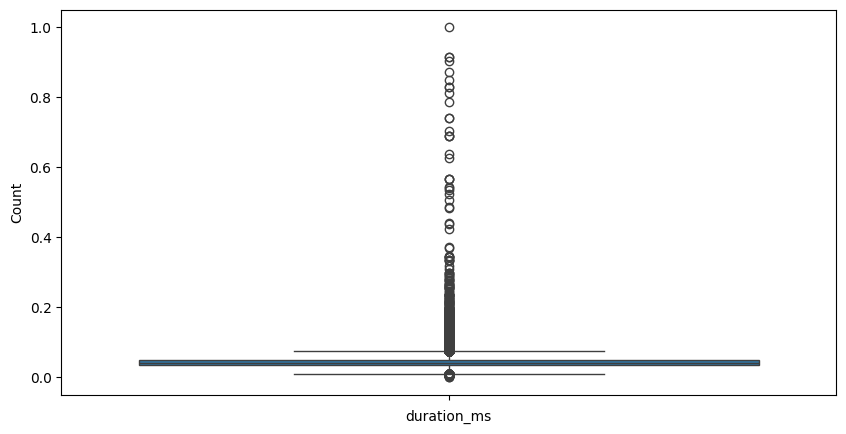

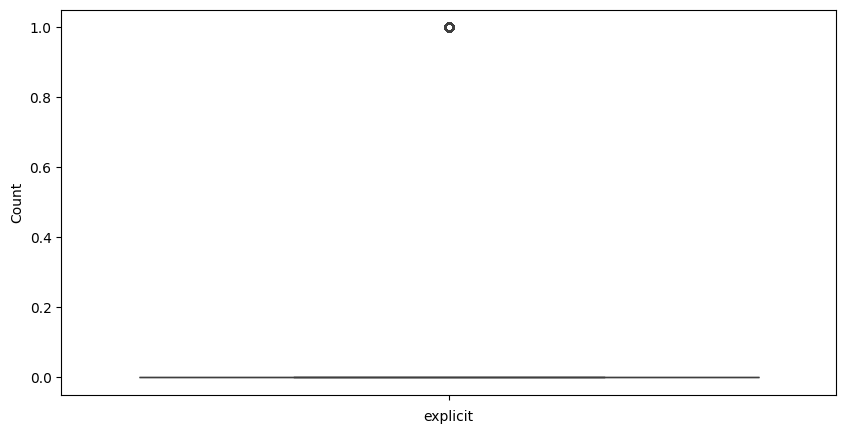

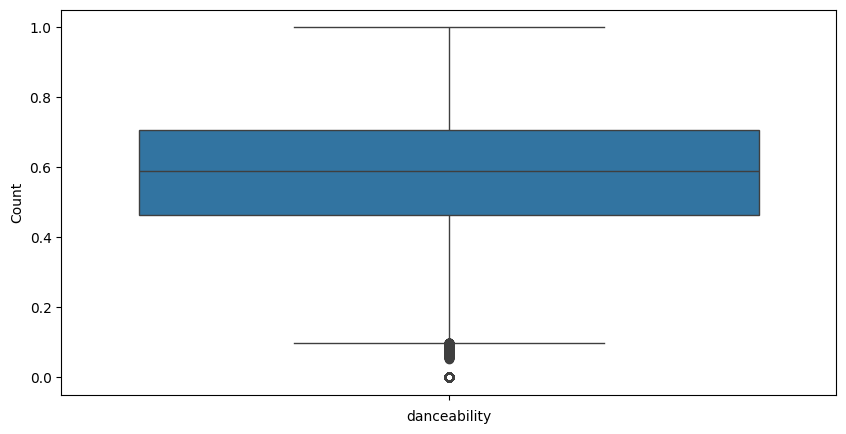

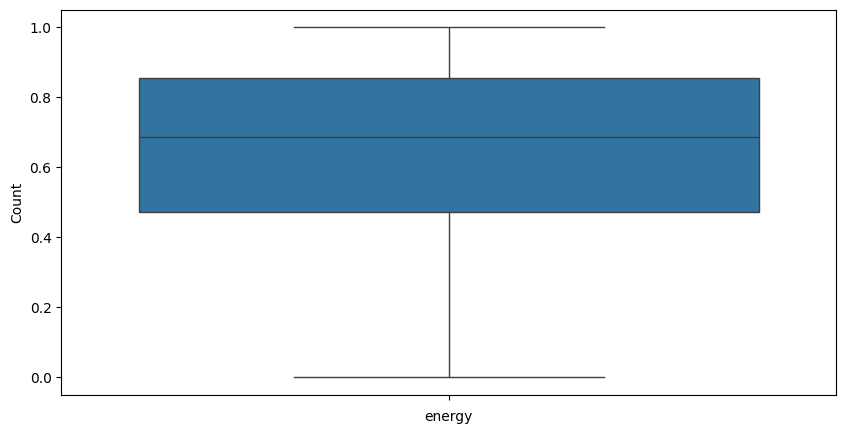

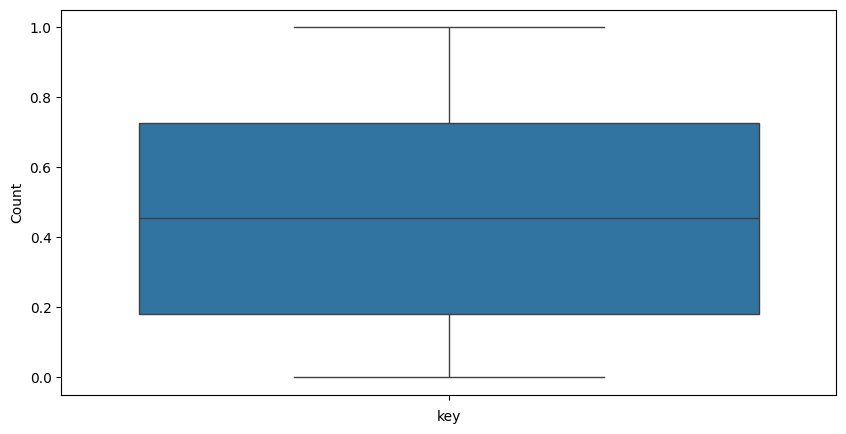

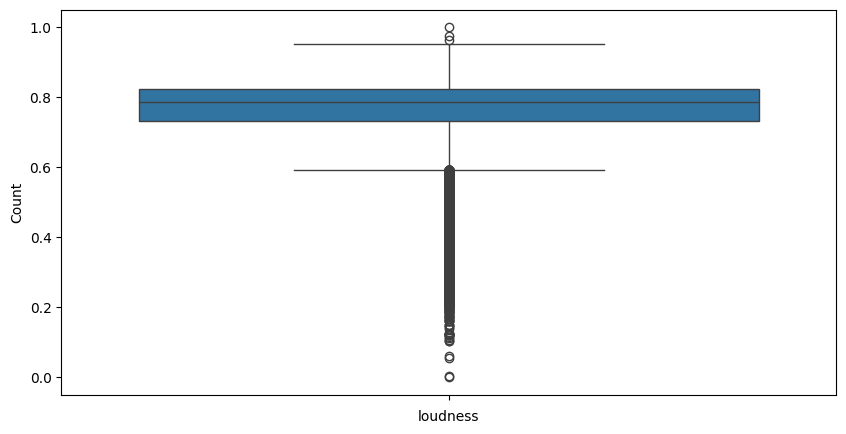

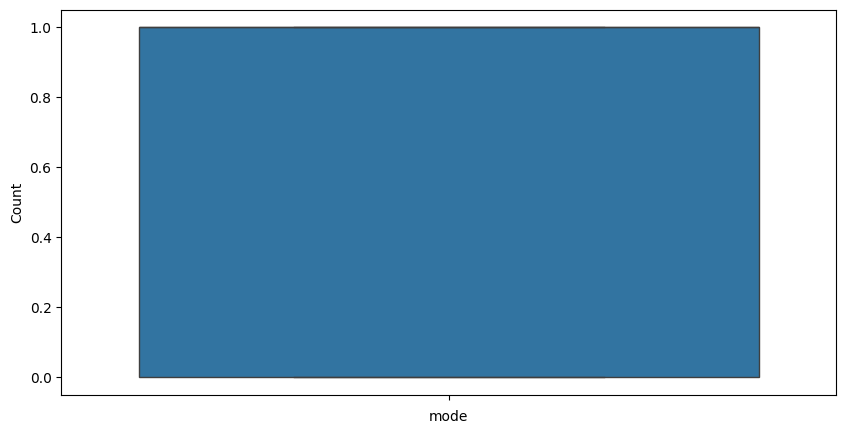

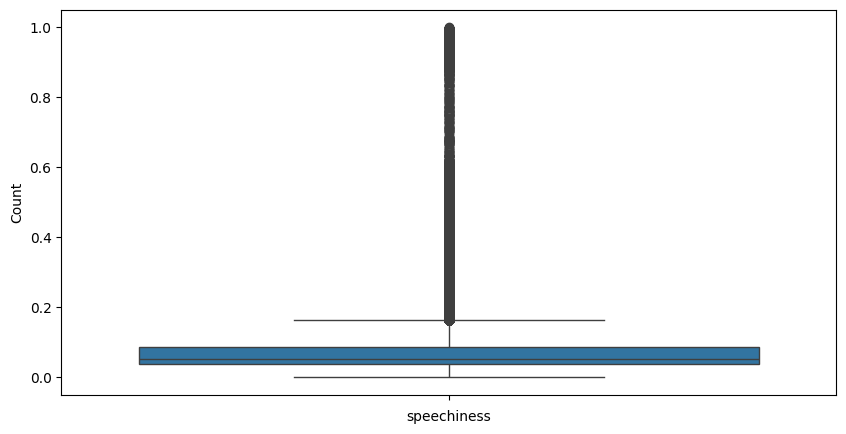

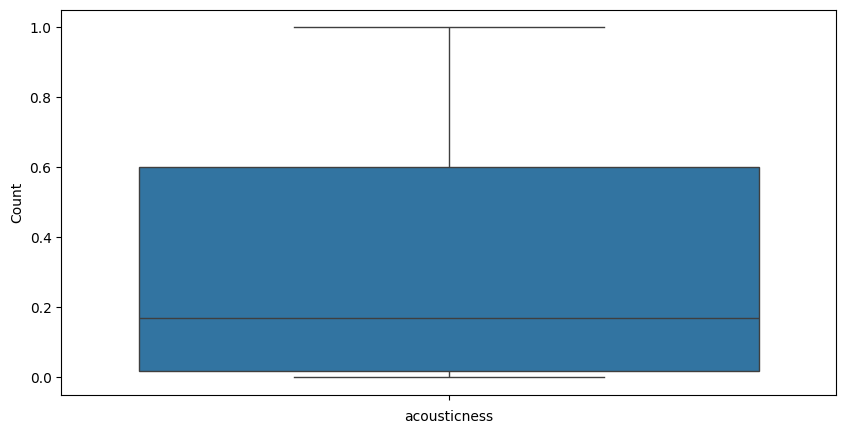

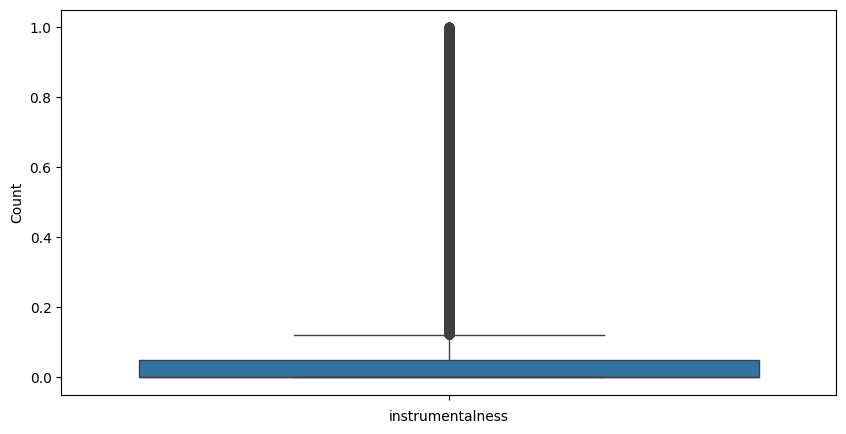

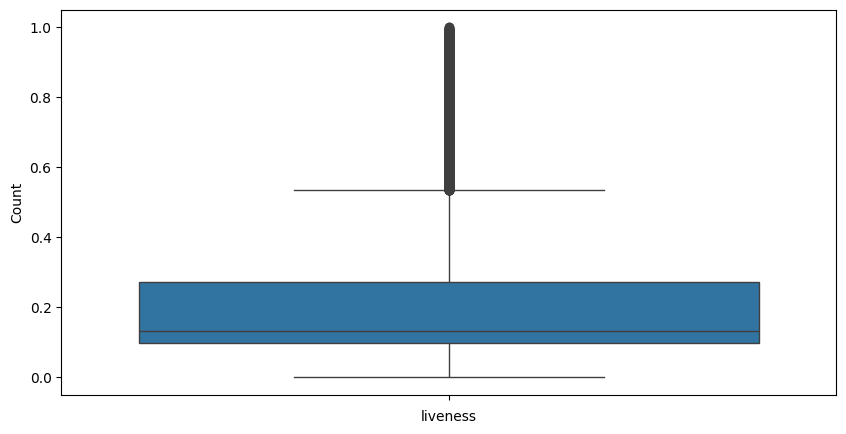

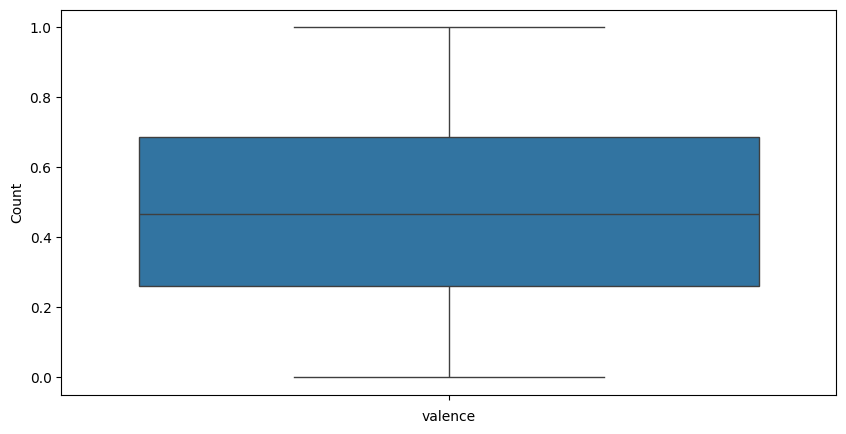

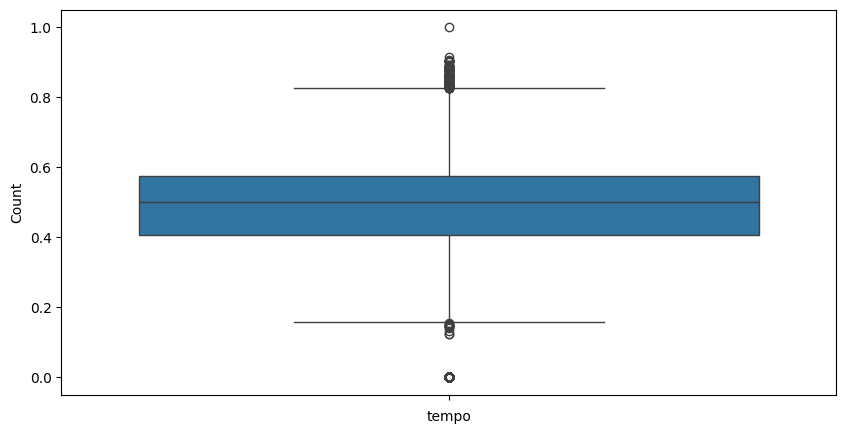

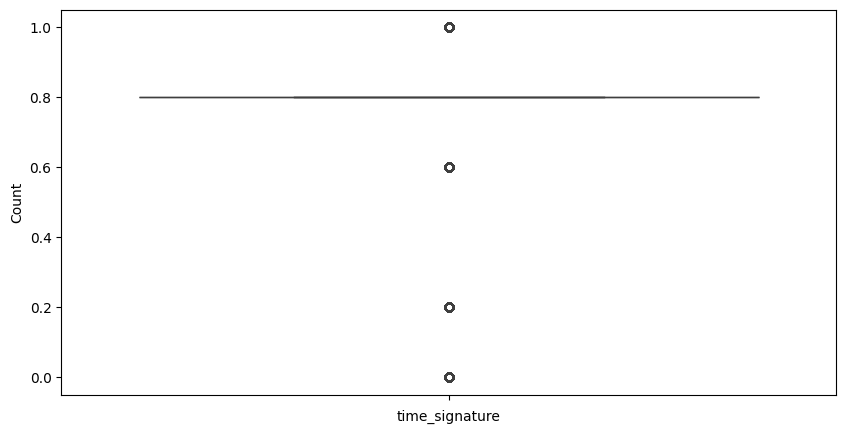

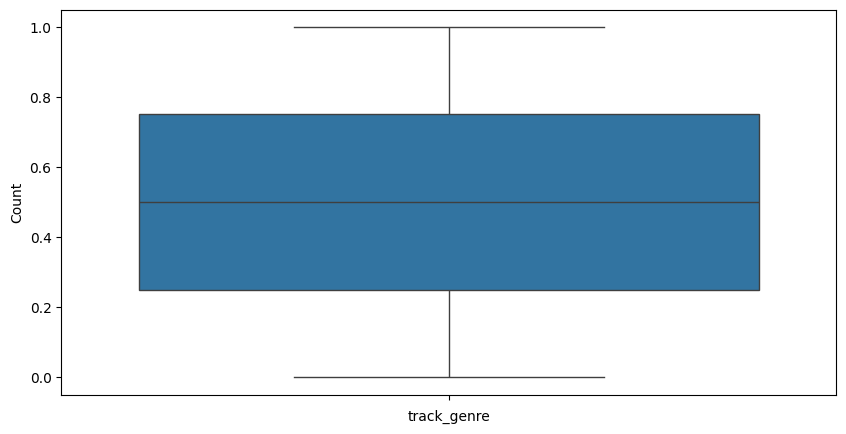

In [238]:
#now finally box plot
features = music_dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(music_dataset[feature])
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

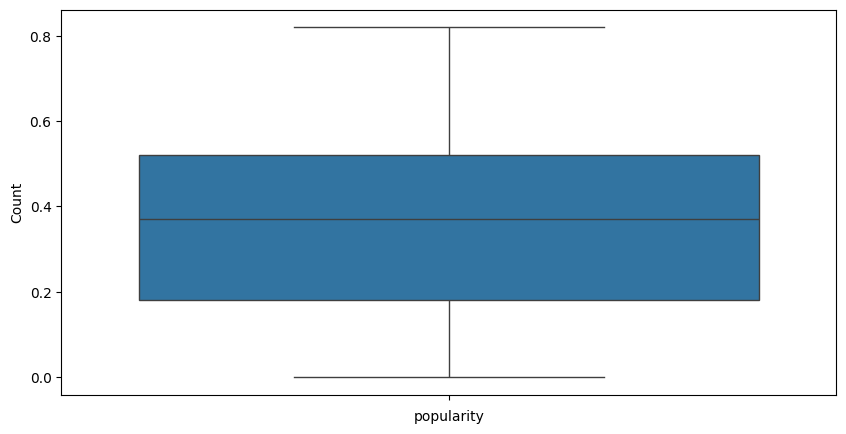

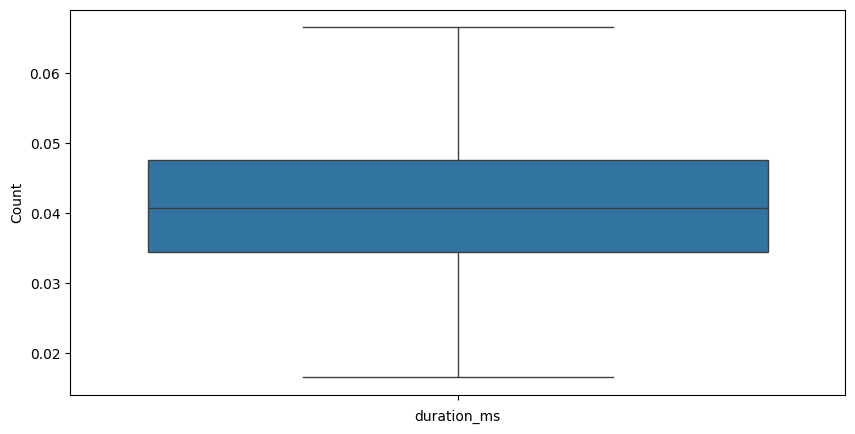

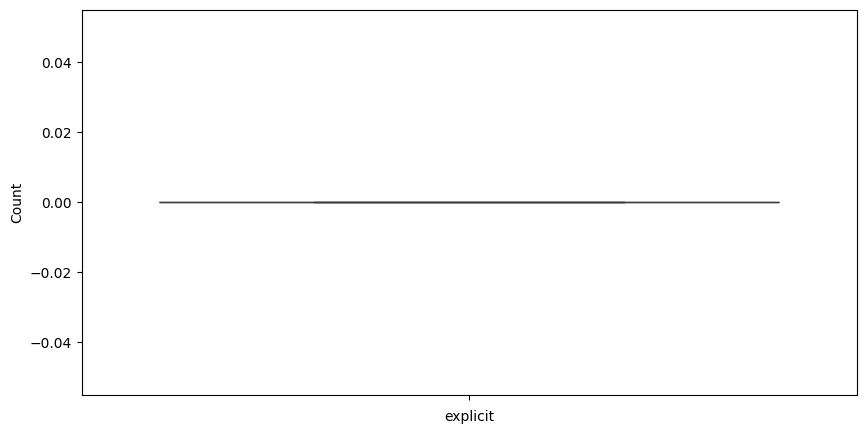

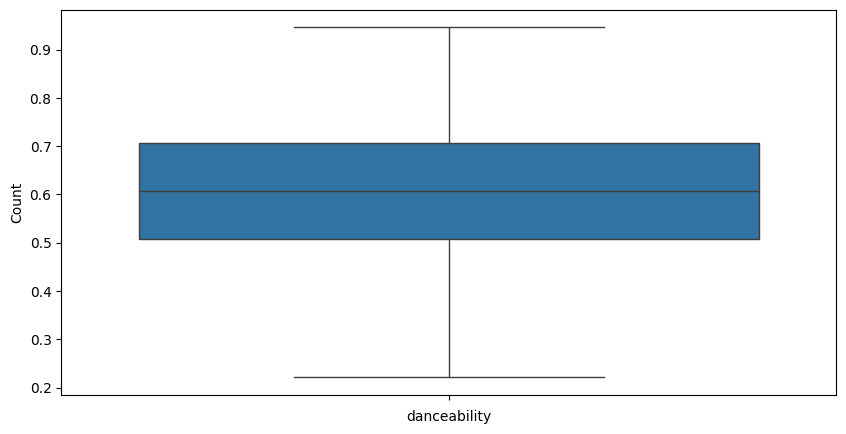

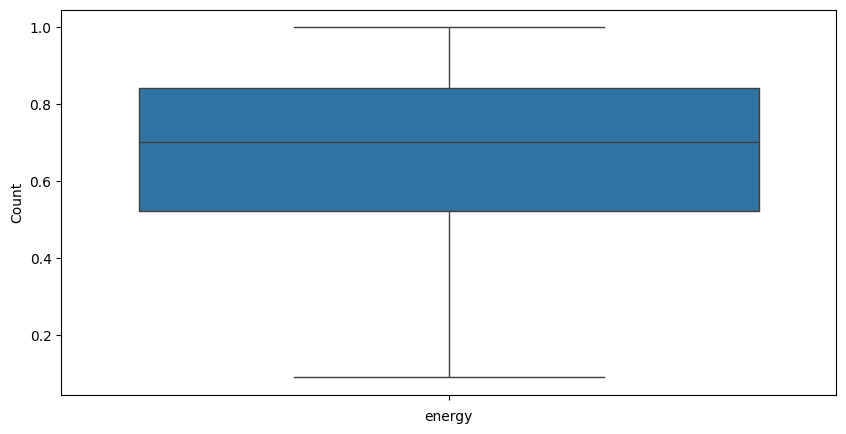

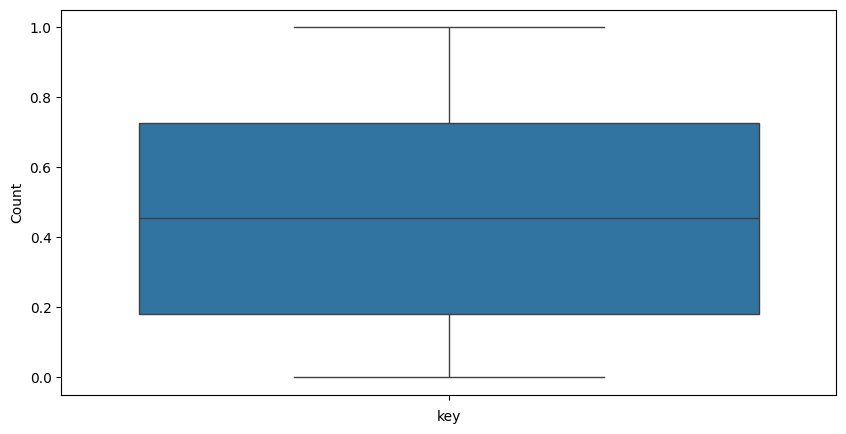

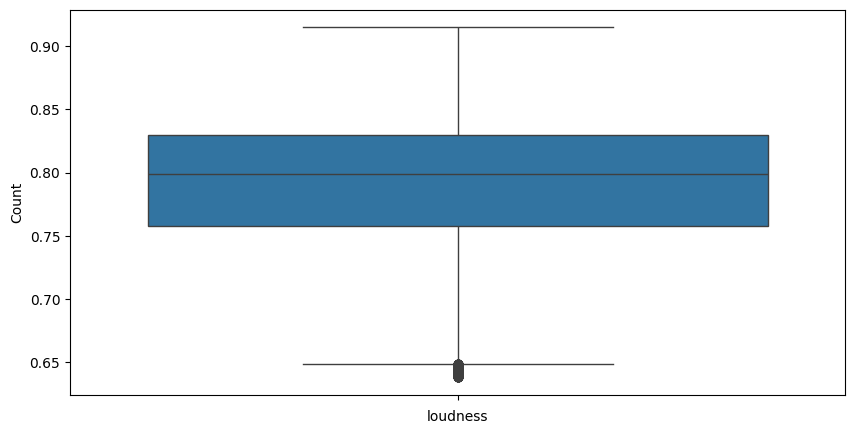

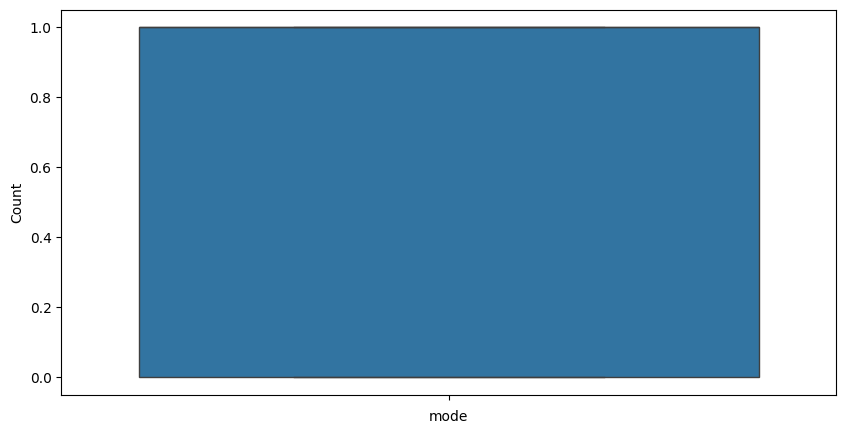

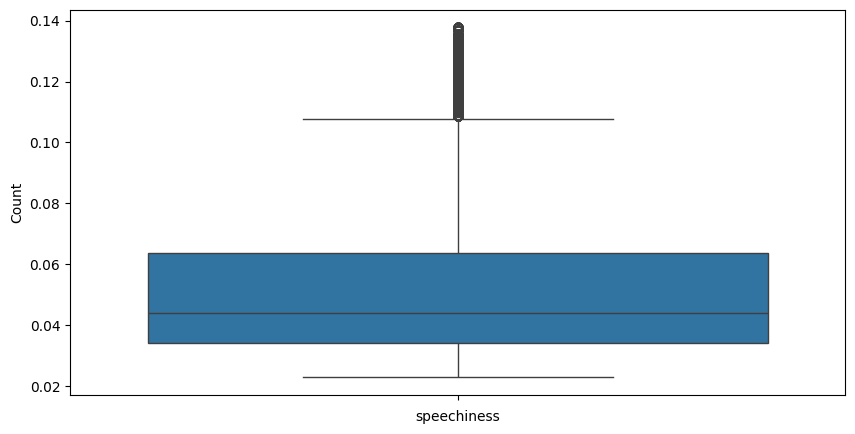

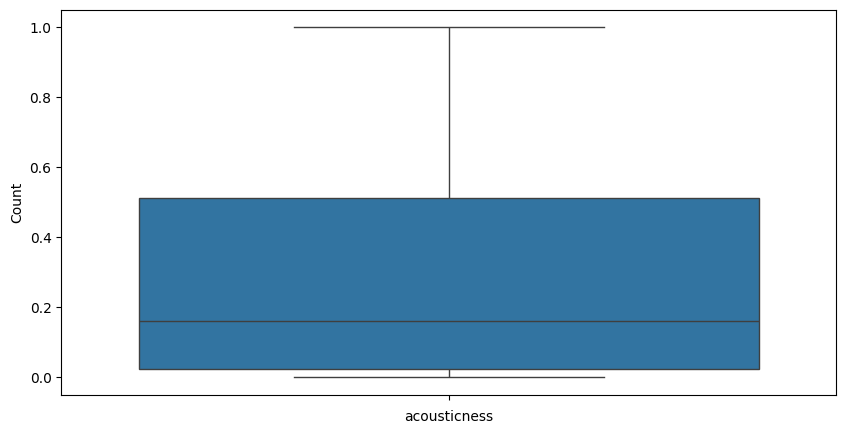

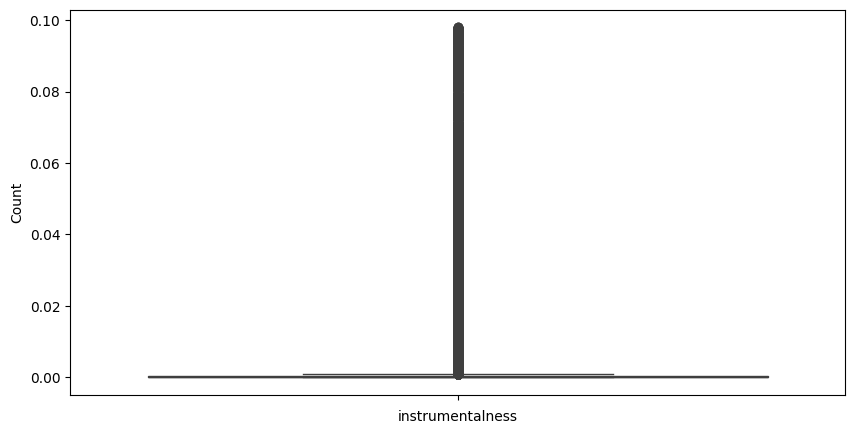

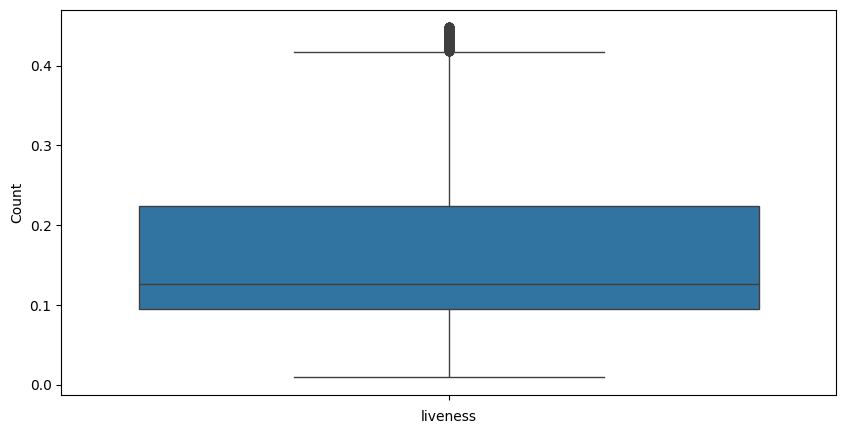

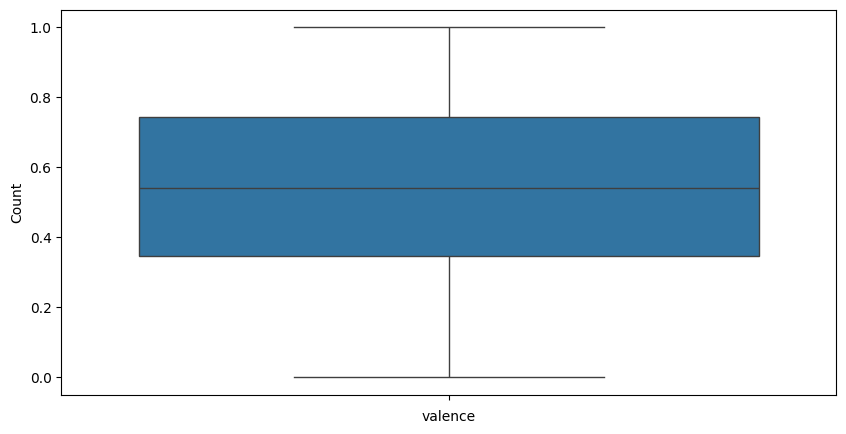

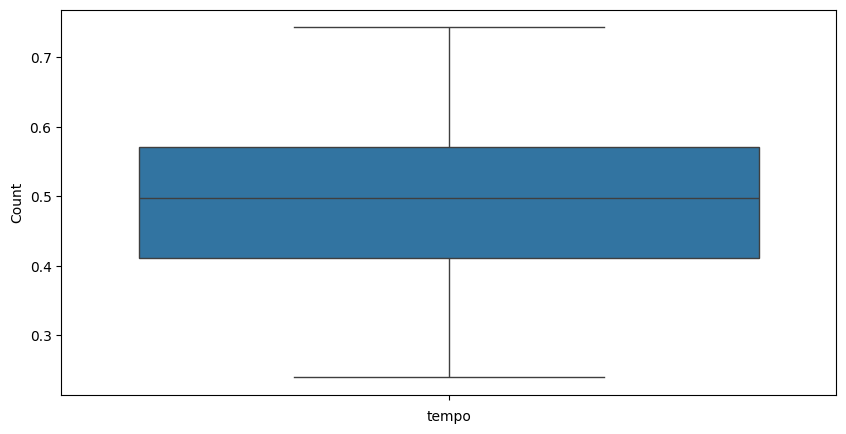

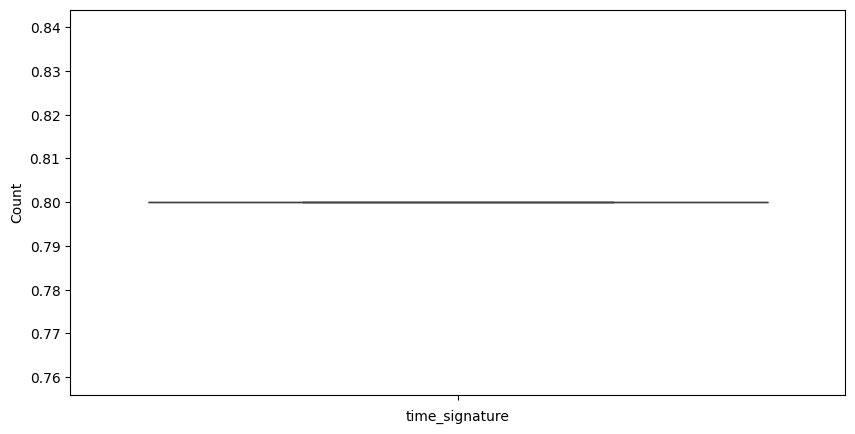

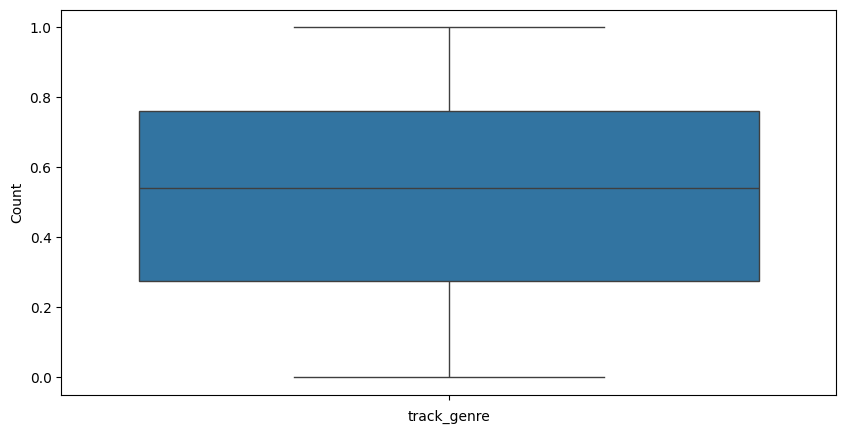

In [239]:
#remove outliers
Q1 = music_dataset.quantile(0.25)
Q3 = music_dataset.quantile(0.75)
IQR = Q3 - Q1
music_dataset = music_dataset[~((music_dataset < (Q1 - 1.0 * IQR)) | (music_dataset > (Q3 + 1.0 * IQR))).any(axis=1)]

features = music_dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(music_dataset[feature])
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

In [240]:
#correlation matrix
correlationMatrix = music_dataset.corr()
correlationMatrix

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
popularity,1.000000,0.091831,NaN,-0.039107,-0.018874,0.000540,-0.002574,-0.022980,-0.042367,-0.008991,0.000557,-0.017458,-0.121299,0.034305,NaN,-0.002700
duration_ms,0.091831,1.000000,NaN,-0.164262,0.058619,0.008271,0.029742,-0.032729,-0.107372,-0.086996,0.047744,-0.047428,-0.202184,0.024600,NaN,-0.006368
explicit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,-0.039107,-0.164262,NaN,1.000000,0.031697,0.018313,0.039641,-0.079108,0.102001,-0.044297,-0.001208,-0.096516,0.447355,-0.144723,NaN,-0.001818
energy,-0.018874,0.058619,NaN,0.031697,1.000000,0.032462,0.739966,-0.113188,0.327872,-0.704583,0.057717,0.163332,0.263725,0.214989,NaN,-0.025596
key,0.000540,0.008271,NaN,0.018313,0.032462,1.000000,0.022875,-0.107341,0.043324,-0.033219,0.009508,-0.012892,0.027991,0.004531,NaN,-0.006601
loudness,-0.002574,0.029742,NaN,0.039641,0.739966,0.022875,1.000000,-0.083663,0.228524,-0.513676,-0.053274,0.114917,0.107113,0.144193,NaN,-0.050570
mode,-0.022980,-0.032729,NaN,-0.079108,-0.113188,-0.107341,-0.083663,1.000000,-0.105354,0.114623,-0.048974,-0.001302,0.018085,-0.005486,NaN,0.002276
speechiness,-0.042367,-0.107372,NaN,0.102001,0.327872,0.043324,0.228524,-0.105354,1.000000,-0.214483,0.006013,0.064381,0.078340,0.102444,NaN,-0.003236
acousticness,-0.008991,-0.086996,NaN,-0.044297,-0.704583,-0.033219,-0.513676,0.114623,-0.214483,1.000000,-0.065571,-0.069489,-0.064692,-0.162960,NaN,0.076230


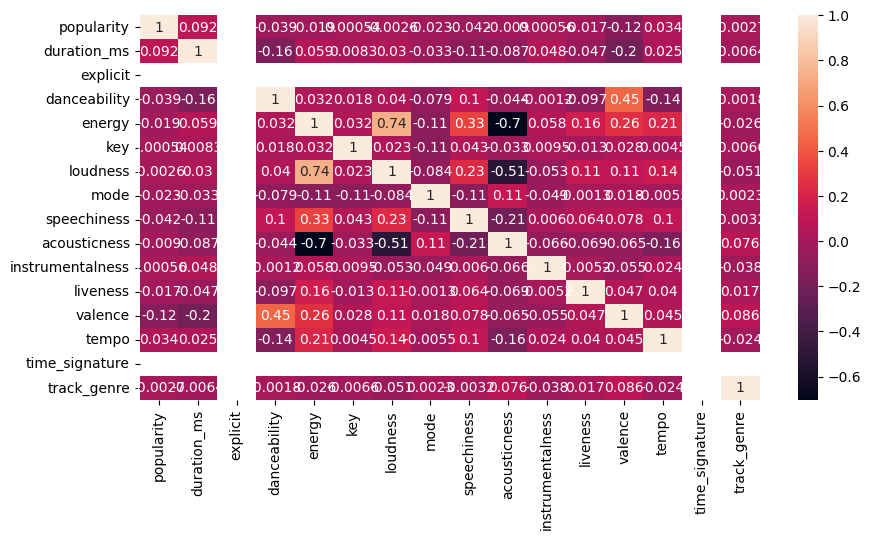

In [241]:
plt.figure(figsize=(10, 5))
sns.heatmap(correlationMatrix, annot=True)
plt.show()

In [242]:
#constant features
features = music_dataset.columns
for feature in features:
    if music_dataset[feature].std() == 0:
        print(feature)
        print(music_dataset[feature].std())
        print('\n')

explicit
0.0




In [243]:
print("Unique time_signature values:", music_dataset['time_signature'].unique())

Unique time_signature values: [0.8]


In [244]:
#remove these useless constant features 
music_dataset.drop(['explicit', 'time_signature'], axis = 1, inplace = True)
music_dataset

/var/folders/_g/3jm_h3c15k34rwm0w2rtr0wh0000gn/T/ipykernel_25176/1547370975.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  music_dataset.drop(['explicit', 'time_signature'], axis = 1, inplace = True)


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
2,0.57,0.040255,0.444670,0.359,0.000000,0.736123,1.0,0.057720,0.210843,0.000000,0.1170,0.120603,0.313643,0.0
4,0.82,0.037969,0.627411,0.443,0.181818,0.737103,1.0,0.054508,0.470884,0.000000,0.0829,0.167839,0.492863,0.0
5,0.58,0.040907,0.698477,0.481,0.545455,0.753269,1.0,0.108808,0.290161,0.000000,0.1890,0.669347,0.402746,0.0
7,0.80,0.046388,0.713706,0.444,1.000000,0.743577,1.0,0.043212,0.561245,0.000000,0.0973,0.715578,0.620285,0.0
8,0.74,0.036204,0.634518,0.414,0.000000,0.755249,1.0,0.038238,0.295181,0.000000,0.1510,0.672362,0.534523,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113991,0.32,0.047855,0.392893,0.531,0.727273,0.827609,1.0,0.030052,0.003062,0.000000,0.2010,0.153769,0.599917,1.0
113992,0.38,0.059681,0.482234,0.860,0.909091,0.828829,1.0,0.043627,0.006526,0.000002,0.2460,0.429146,0.468209,1.0
113997,0.22,0.051833,0.638579,0.329,0.000000,0.714648,0.0,0.043523,0.870482,0.000000,0.0839,0.746734,0.543933,1.0
113998,0.41,0.054206,0.595939,0.506,0.636364,0.714759,1.0,0.030777,0.382530,0.000000,0.2700,0.415075,0.558651,1.0


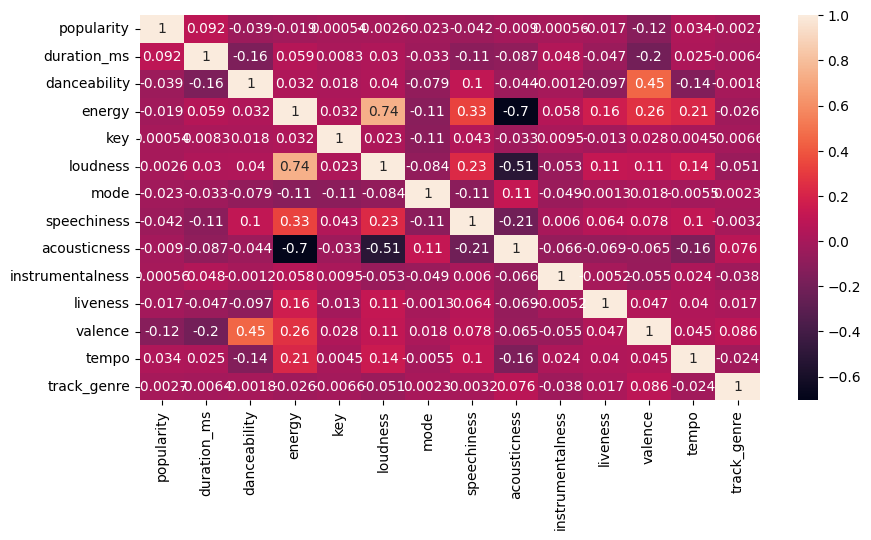

In [245]:
correlationMatrix2 = music_dataset.corr()

plt.figure(figsize=(10, 5))
sns.heatmap(correlationMatrix2, annot=True)
plt.show()